In [12]:
!pip -q install captum

In [13]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from torchvision import models

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.relu3 = nn.ReLU()
        self.relu4 = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = self.relu3(self.fc1(x))
        x = self.relu4(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)



Files already downloaded and verified
Files already downloaded and verified


In [15]:
USE_PRETRAINED_MODEL = True

if USE_PRETRAINED_MODEL:
    print("Using existing trained model")
    net.load_state_dict(torch.load('cifar_torchvision.pt'))
else:
    for epoch in range(5):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs
            inputs, labels = data
            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 2000 == 1999:    # print every 2000 mini-batches
                print('[%d, %5d] loss: %.3f' %
                      (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0

    print('Finished Training')
    torch.save(net.state_dict(), 'models/cifar_torchvision.pt')

Using existing trained model


<ipython-input-15-a935ee5303e7>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load('cifar_torchvision.pt'))


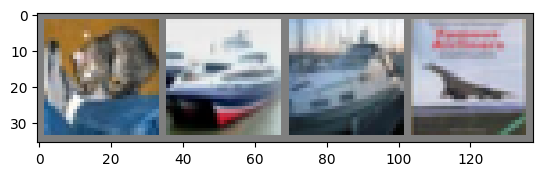

GroundTruth:    cat  ship  ship plane
Predicted:    cat  ship  ship  ship


In [16]:
from captum.attr import IntegratedGradients
from captum.attr import Saliency
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))


outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))



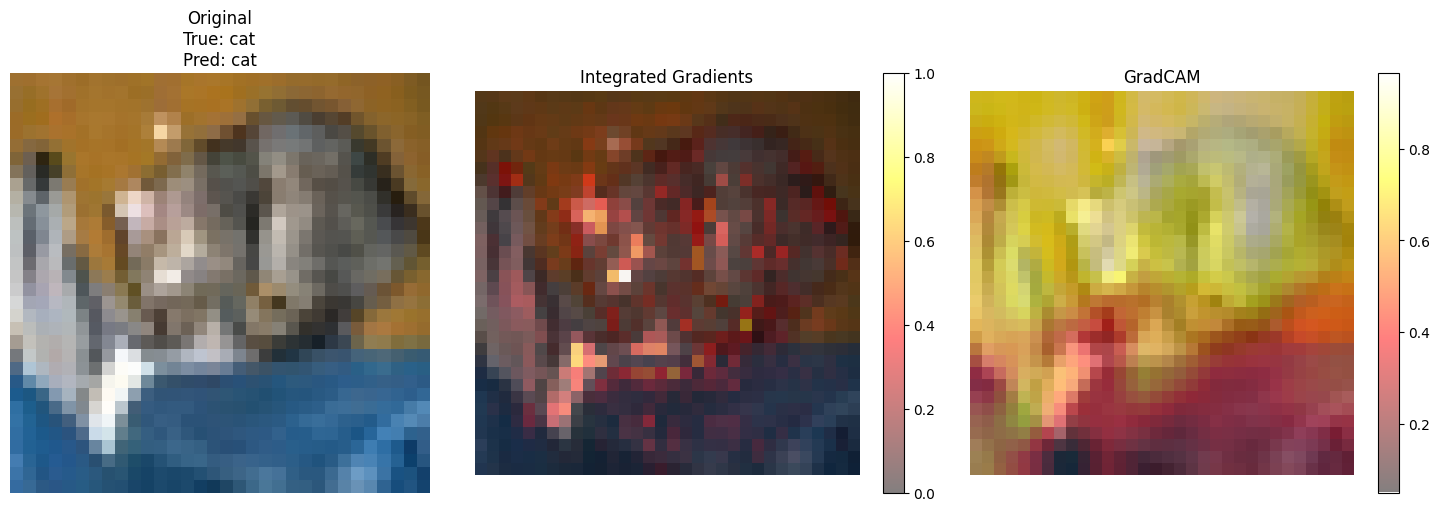

In [17]:
from captum.attr import IntegratedGradients, LayerGradCam
import torch.nn.functional as F

# Prepariamo l'immagine
dataiter = iter(testloader)
images, labels = next(dataiter)
input_img = images[0].unsqueeze(0)
input_label = labels[0]

# 1. Integrated Gradients
ig = IntegratedGradients(net)
ig_attr = ig.attribute(input_img, target=input_label, n_steps=50)

# 2. GradCAM - dobbiamo specificare il layer
layer_gradcam = LayerGradCam(net, net.conv2)  # usando l'ultimo layer convoluzionale
gradcam_attr = layer_gradcam.attribute(input_img, target=input_label)

# Visualizzazione
plt.figure(figsize=(15, 5))

# 1. Immagine originale
plt.subplot(131)
orig_img = input_img.squeeze().cpu().detach().numpy()
orig_img = np.transpose(orig_img, (1, 2, 0))
plt.imshow(orig_img * 0.5 + 0.5)
plt.title(f'Original\nTrue: {classes[labels[0]]}\nPred: {classes[predicted[0]]}')
plt.axis('off')

# 2. Integrated Gradients Map sovrapposta
plt.subplot(132)
ig_map = ig_attr.abs().sum(dim=1).squeeze().cpu().detach().numpy()
ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min())

plt.imshow(orig_img * 0.5 + 0.5)
plt.imshow(ig_map, cmap='hot', alpha=0.5)
plt.title('Integrated Gradients')
plt.colorbar()
plt.axis('off')

# 3. GradCAM Map sovrapposta
plt.subplot(133)
gradcam_map = gradcam_attr.squeeze().cpu().detach().numpy()
gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min())

# Ridimensioniamo la GradCAM map alla dimensione dell'immagine originale
gradcam_map = F.interpolate(torch.tensor(gradcam_map).unsqueeze(0).unsqueeze(0),
                         size=(32, 32),
                         mode='bilinear',
                         align_corners=False).squeeze().numpy()

plt.imshow(orig_img * 0.5 + 0.5)
plt.imshow(gradcam_map, cmap='hot', alpha=0.5)
plt.title('GradCAM')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()


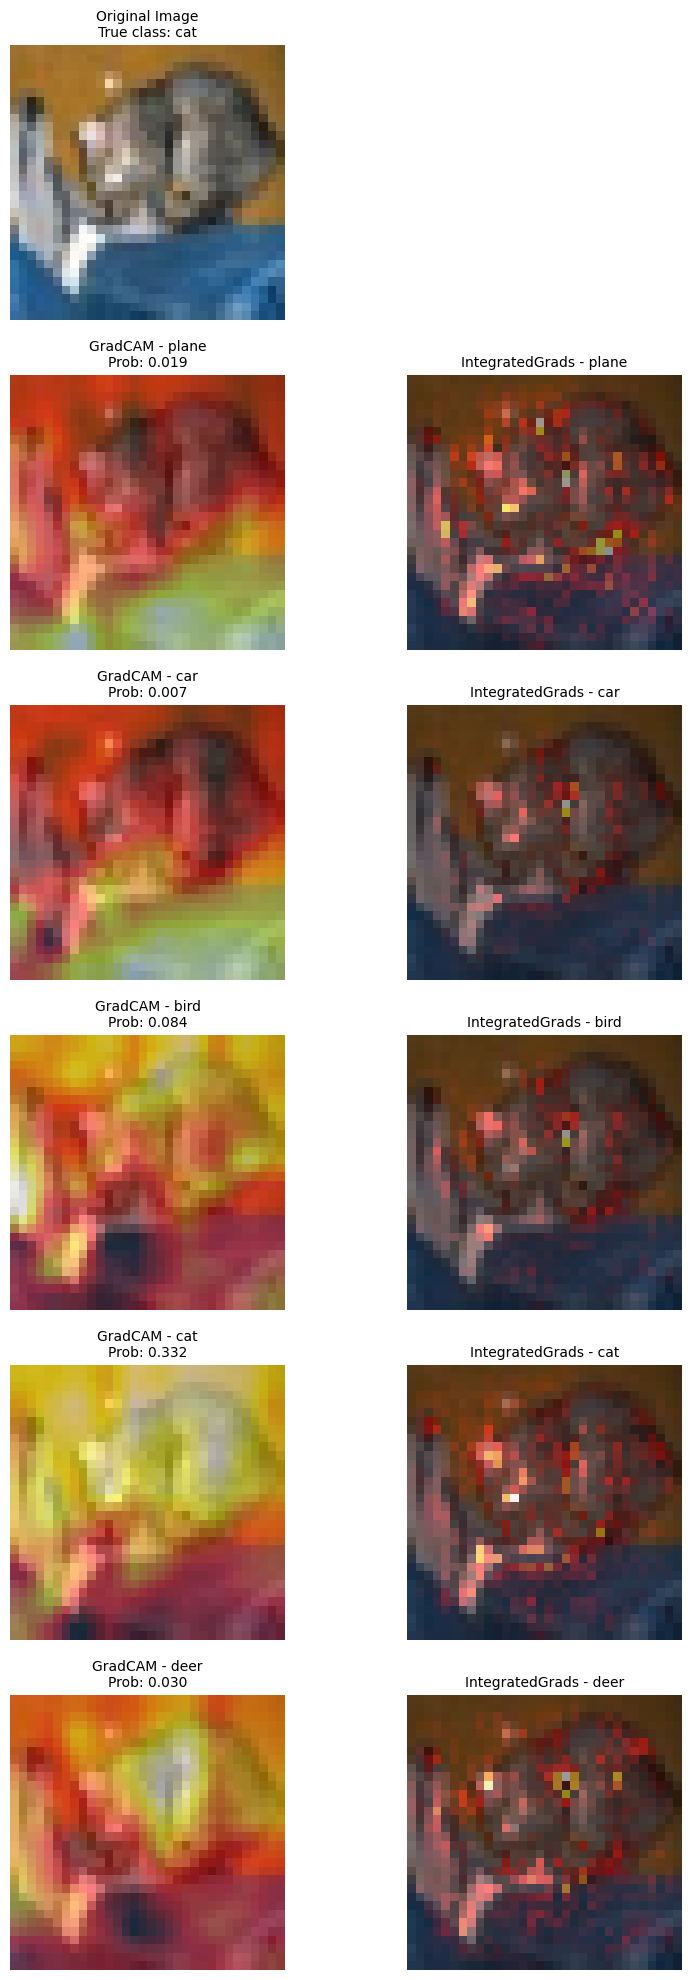

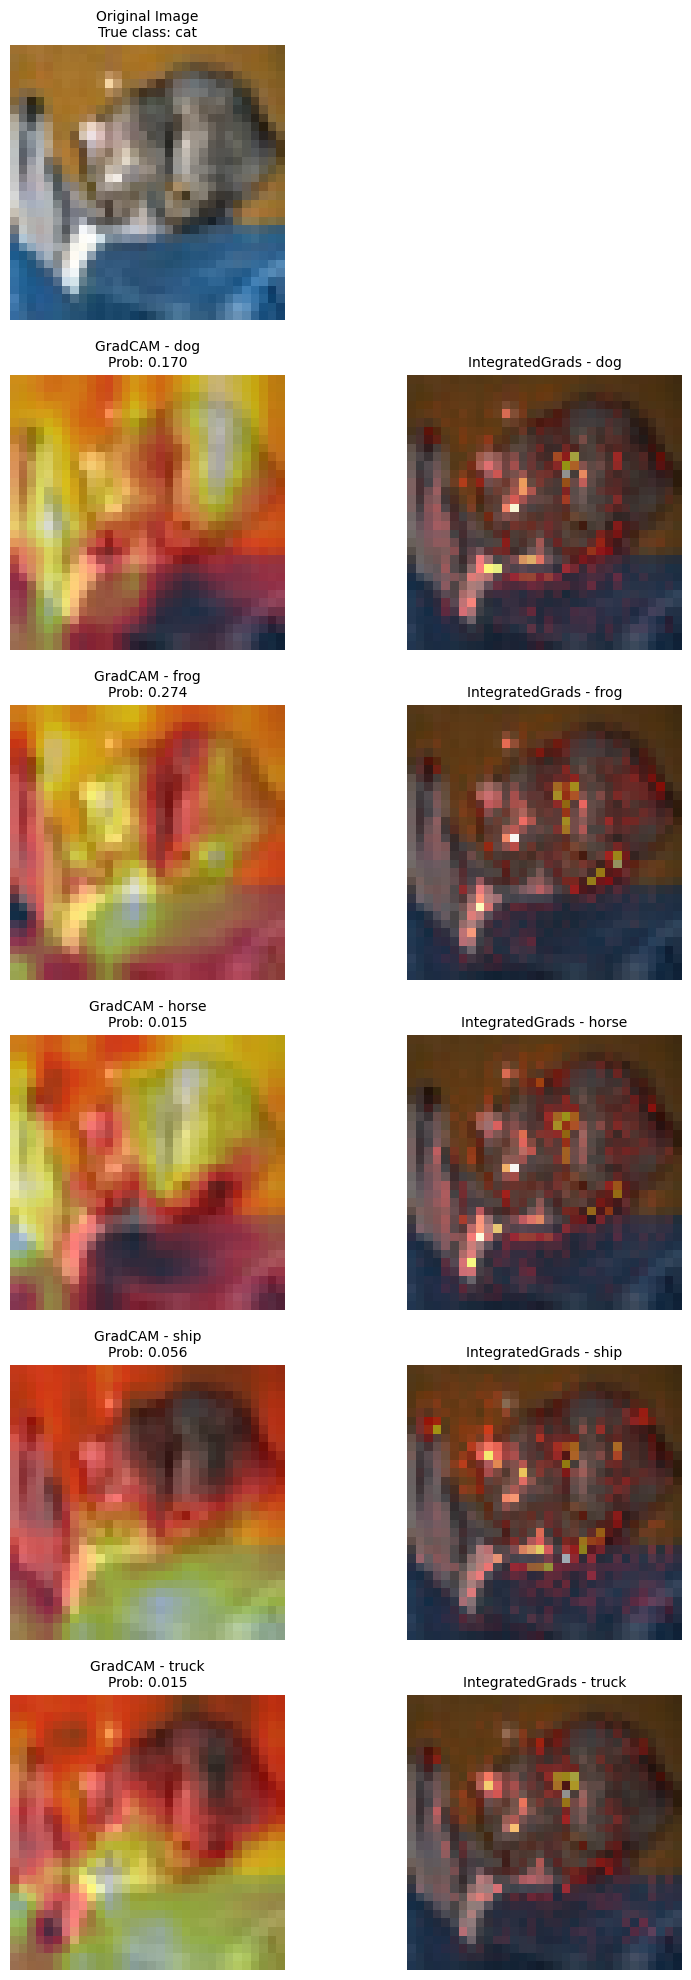

In [8]:
from captum.attr import IntegratedGradients, LayerGradCam
import torch.nn.functional as F
import math

# Prepariamo l'immagine
dataiter = iter(testloader)
images, labels = next(dataiter)
input_img = images[0].unsqueeze(0)
true_label = labels[0]

# Output della rete
with torch.no_grad():
   output = net(input_img)
   probs = F.softmax(output, dim=1)[0]

# Inizializziamo i modelli
ig = IntegratedGradients(net)
layer_gradcam = LayerGradCam(net, net.conv2)

# Prima cinque classi
plt.figure(figsize=(10, 25))

# Immagine originale in alto
plt.subplot(6, 2, 1)
orig_img = input_img.squeeze().cpu().detach().numpy()
orig_img = np.transpose(orig_img, (1, 2, 0))
plt.imshow(orig_img * 0.5 + 0.5)
plt.title(f'Original Image\nTrue class: {classes[true_label]}', fontsize=10)
plt.axis('off')

# Prime 5 classi
for i in range(5):
   # GradCAM
   gradcam_attr = layer_gradcam.attribute(input_img, target=i)
   gradcam_map = gradcam_attr.squeeze().cpu().detach().numpy()
   gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min())
   gradcam_map = F.interpolate(torch.tensor(gradcam_map).unsqueeze(0).unsqueeze(0),
                             size=(32, 32),
                             mode='bilinear',
                             align_corners=False).squeeze().numpy()

   # Integrated Gradients
   ig_attr = ig.attribute(input_img, target=i, n_steps=50)
   ig_map = ig_attr.abs().sum(dim=1).squeeze().cpu().detach().numpy()
   ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min())

   # Plot GradCAM
   plt.subplot(6, 2, 2*i + 3)
   plt.imshow(orig_img * 0.5 + 0.5)
   plt.imshow(gradcam_map, cmap='hot', alpha=0.5)
   plt.title(f'GradCAM - {classes[i]}\nProb: {probs[i]:.3f}', fontsize=10)
   plt.axis('off')

   # Plot Integrated Gradients
   plt.subplot(6, 2, 2*i + 4)
   plt.imshow(orig_img * 0.5 + 0.5)
   plt.imshow(ig_map, cmap='hot', alpha=0.5)
   plt.title(f'IntegratedGrads - {classes[i]}', fontsize=10)
   plt.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.show()

# Seconda parte del codice, per le classi 5-9
plt.figure(figsize=(10, 25))

# Immagine originale in alto
plt.subplot(6, 2, 1)
plt.imshow(orig_img * 0.5 + 0.5)
plt.title(f'Original Image\nTrue class: {classes[true_label]}', fontsize=10)
plt.axis('off')

# Seconde 5 classi
for i in range(5, 10):
    # GradCAM
    gradcam_attr = layer_gradcam.attribute(input_img, target=i)
    gradcam_map = gradcam_attr.squeeze().cpu().detach().numpy()
    gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min())
    gradcam_map = F.interpolate(torch.tensor(gradcam_map).unsqueeze(0).unsqueeze(0),
                              size=(32, 32),
                              mode='bilinear',
                              align_corners=False).squeeze().numpy()

    # Integrated Gradients
    ig_attr = ig.attribute(input_img, target=i, n_steps=50)
    ig_map = ig_attr.abs().sum(dim=1).squeeze().cpu().detach().numpy()
    if ig_map.max() != ig_map.min():  # Aggiungiamo un controllo
        ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min())
    else:
        ig_map = np.zeros_like(ig_map)

    # Plot GradCAM
    j = i - 5  # Indice locale per le seconde 5 classi
    plt.subplot(6, 2, 2*j + 3)  # Usa j invece di (i-5)
    plt.imshow(orig_img * 0.5 + 0.5)
    plt.imshow(gradcam_map, cmap='hot', alpha=0.5)
    plt.title(f'GradCAM - {classes[i]}\nProb: {probs[i]:.3f}', fontsize=10)
    plt.axis('off')

    # Plot Integrated Gradients
    plt.subplot(6, 2, 2*j + 4)  # Usa j invece di (i-5)
    plt.imshow(orig_img * 0.5 + 0.5)
    plt.imshow(ig_map, cmap='hot', alpha=0.5)
    plt.title(f'IntegratedGrads - {classes[i]}', fontsize=10)
    plt.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.show()

# Modello preaddestrato

Classe gatto: tabby
Classe cane: bull mastiff


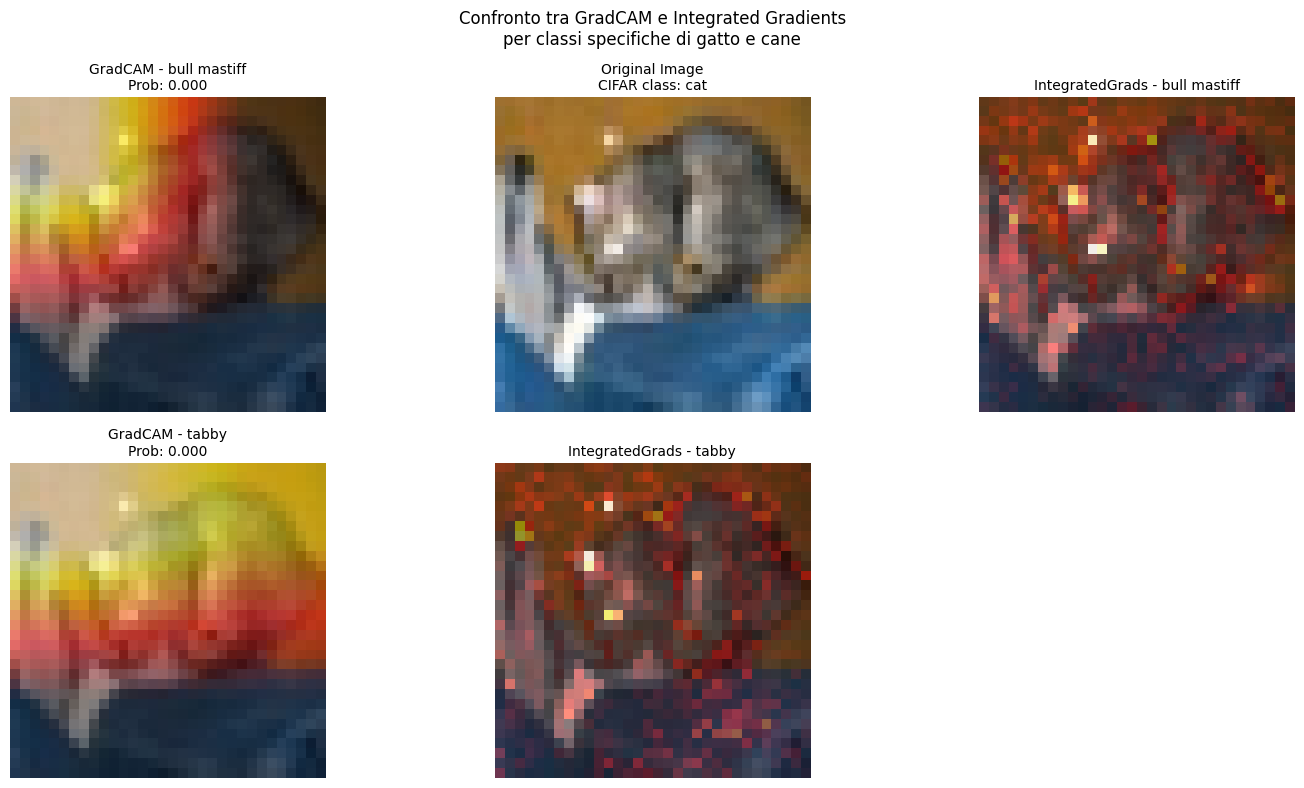

In [11]:
from captum.attr import IntegratedGradients, LayerGradCam
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import math
import numpy as np

# Carichiamo ResNet50 pre-addestrato
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model.eval()

# Otteniamo le classi di ImageNet
weights = ResNet50_Weights.DEFAULT
imagenet_classes = weights.meta["categories"]

# Scegliamo una classe specifica per gatto e cane
cat_idx = 281  # 'tabby cat'
dog_idx = 243  # 'bulldog'

print(f"Classe gatto: {imagenet_classes[cat_idx]}")
print(f"Classe cane: {imagenet_classes[dog_idx]}")

# Prendiamo l'immagine
dataiter = iter(testloader)
images, cifar_labels = next(dataiter)
input_img = images[0].unsqueeze(0)

# Output della rete
with torch.no_grad():
   output = model(input_img)
   probs = F.softmax(output, dim=1)[0]

# Inizializziamo i modelli di interpretabilità
ig = IntegratedGradients(model)
layer_gradcam = LayerGradCam(model, model.layer3[-1])

def process_gradcam(attr, target_size=(32, 32)):
   if attr.nelement() == 0:
       return np.zeros(target_size)

   pooled = attr.max(dim=1)[0].squeeze()
   if pooled.dim() < 2:
       return np.zeros(target_size)

   heatmap = pooled.cpu().detach().numpy()
   heatmap = np.maximum(heatmap, 0)
   if heatmap.max() > 0:
       heatmap = heatmap / heatmap.max()

   import cv2
   heatmap = cv2.resize(heatmap, target_size)

   return heatmap

# Visualizzazione
plt.figure(figsize=(15, 8))

# Immagine originale
plt.subplot(2, 3, 2)
orig_img = input_img.squeeze().cpu().detach().numpy()
orig_img = np.transpose(orig_img, (1, 2, 0))
plt.imshow(orig_img * 0.5 + 0.5)
plt.title(f'Original Image\nCIFAR class: {classes[cifar_labels[0]]}', fontsize=10)
plt.axis('off')

# GradCAM per gatto
plt.subplot(2, 3, 4)
gradcam_attr = layer_gradcam.attribute(input_img, target=cat_idx)
gradcam_map = process_gradcam(gradcam_attr)
plt.imshow(orig_img * 0.5 + 0.5)
plt.imshow(gradcam_map, cmap='hot', alpha=0.5)
plt.title(f'GradCAM - {imagenet_classes[cat_idx]}\nProb: {probs[cat_idx]:.3f}', fontsize=10)
plt.axis('off')

# IntegratedGradients per gatto
plt.subplot(2, 3, 5)
ig_attr = ig.attribute(input_img, target=cat_idx, n_steps=50)
ig_map = ig_attr.abs().sum(dim=1).squeeze().cpu().detach().numpy()
ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min())
plt.imshow(orig_img * 0.5 + 0.5)
plt.imshow(ig_map, cmap='hot', alpha=0.5)
plt.title(f'IntegratedGrads - {imagenet_classes[cat_idx]}', fontsize=10)
plt.axis('off')

# GradCAM per cane
plt.subplot(2, 3, 1)
gradcam_attr = layer_gradcam.attribute(input_img, target=dog_idx)
gradcam_map = process_gradcam(gradcam_attr)
plt.imshow(orig_img * 0.5 + 0.5)
plt.imshow(gradcam_map, cmap='hot', alpha=0.5)
plt.title(f'GradCAM - {imagenet_classes[dog_idx]}\nProb: {probs[dog_idx]:.3f}', fontsize=10)
plt.axis('off')

# IntegratedGradients per cane
plt.subplot(2, 3, 3)
ig_attr = ig.attribute(input_img, target=dog_idx, n_steps=50)
ig_map = ig_attr.abs().sum(dim=1).squeeze().cpu().detach().numpy()
ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min())
plt.imshow(orig_img * 0.5 + 0.5)
plt.imshow(ig_map, cmap='hot', alpha=0.5)
plt.title(f'IntegratedGrads - {imagenet_classes[dog_idx]}', fontsize=10)
plt.axis('off')

plt.suptitle('Confronto tra GradCAM e Integrated Gradients\nper classi specifiche di gatto e cane', fontsize=12)
plt.tight_layout()
plt.show()